In [4]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline

import joblib
import random
import numpy as np
from scipy.stats import linregress
import torch
from matplotlib import pyplot as plt
from syd import make_viewer, Viewer
from tqdm import tqdm
from rastermap import Rastermap
import optuna

from vrAnalysis.database import get_database
from vrAnalysis.helpers import Timer, sort_by_preferred_environment, edge2center, beeswarm, format_spines, insert_nans_at_gaps, cross_validate_trials, save_figure, add_scaled_limits
from vrAnalysis.sessions import B2Session, SpksTypes
from vrAnalysis.processors import SpkmapProcessor
from vrAnalysis.processors.support import median_zscore
from vrAnalysis.processors.placefields import get_placefield, get_frame_behavior, get_placefield_prediction
from dimilibi import Population
from dimilibi import ReducedRankRegression, RidgeRegression
from dimilibi import measure_r2, mse
from dimilibi.pca import PCA
from dimilibi.cvpca import RegularizedCVPCA, CVPCA
from dimilibi import gaussian_filter, fit_powerlaw_decay, fit_powerlaw_derivatives
from dimensionality_manuscript.registry import PopulationRegistry, get_model, ModelName, short_model_name
from dimensionality_manuscript.workflows.measure_cvpca import get_filepath as get_cvpca_filepath
from dimensionality_manuscript.workflows.measure_cvpca import nanmax
from dimensionality_manuscript import CVPCAConfig, get_data_config, ResultsStore, ResultsAggregator

plt.rcParams["font.size"] = 18

# get session database
sessiondb = get_database("vrSessions")

# get population registry and models
registry = PopulationRegistry()

In [5]:
data_config = get_data_config()
cfg = CVPCAConfig()
sessions = sessiondb.iter_sessions(imaging=True)
store = ResultsStore()
results = ResultsAggregator(cfg, store, sessions, data_config)

In [6]:
# Plot zero map for different combos (maybe either by mouse or not?)
class CVPCAViewer(Viewer):
    def __init__(self):
        self = cfg.build_syd(self, results, no_filter="use_spatial_eigenvectors")

        self._data_options = {
            "org": ("org_covariances", "org_variances_train", "org_variances_test"),
            "org_smooth": ("org_smooth_covariances", "org_smooth_variances_train", "org_smooth_variances_test"),
            "org_fixed": ("org_fixed_smooth_covariances", "org_fixed_smooth_variances_train", "org_fixed_smooth_variances_test"),
            "reg": ("reg_covariances", "reg_variances_train", "reg_variances_test"),
            "reg_fixed": ("reg_covariances_fixed", "reg_fixed_smooth_variances_train", "reg_fixed_smooth_variances_test"),
        }
        self.add_selection("version", options=sorted(self._data_options.keys()), value="reg")
        self.update_selection("normalize", value=False)
        self.update_selection("view_by", value="session")
        self.add_boolean("hide_spatial_curve", value=False)

    def plot(self, state):
        result, axes_names = self.get_result(state)
        cov, var_train, var_test = (result[k] for k in self._data_options[state["version"]])
        if cov.ndim == 1:
            cov = cov[None]
            var_train = var_train[None]
            var_test = var_test[None]

        _idx_all_nan = np.any(np.all(np.isnan(cov), axis=2), axis=1)
        cov = cov[~_idx_all_nan]

        positive = 1.0 * (cov > 0)
        positive[np.isnan(cov)] = np.nan
        pos_neurons = positive[:, 0]
        pos_spatial = positive[:, 1]

        ylabel = "mouse average" if state["view_by"] == "mouse_average" else "session"
        cmap = plt.colormaps["gray_r"]
        cmap.set_bad("lightcoral")

        fig, ax = plt.subplots(3, 1, figsize=(6, 7), height_ratios=[1, 1, 0.8], layout="constrained", sharex=True)
        ax[0].imshow(pos_neurons, aspect="auto", vmin=0, vmax=1, cmap=cmap, interpolation="none")
        ax[1].imshow(pos_spatial, aspect="auto", vmin=0, vmax=1, cmap=cmap, interpolation="none")
        ax[0].set_ylabel(ylabel)
        ax[1].set_ylabel(ylabel)
        ax[0].set_title("cov < 0")
        ax[2].plot(np.nanmean(pos_neurons, axis=0), label="neuron", color="k")
        if not state["hide_spatial_curve"]:
            ax[2].plot(np.nanmean(pos_spatial, axis=0), label="spatial", color="r")
        ax[2].set_ylim(-0.05, 1.05)
        ax[2].legend(fontsize=10)
        ax[2].set_ylabel("fraction < 0")

        return fig


viewer = CVPCAViewer()
viewer.show()

C:\Users\Andrew\Documents\GitHub\vrAnalysis\dimensionality_manuscript\pipeline\aggregate.py:351: RuntimeWarning: Mean of empty slice
C:\Users\Andrew\Documents\GitHub\vrAnalysis\dimensionality_manuscript\pipeline\base.py:166: UserWarning: Skipping ragged key 'smoothing_widths' in average_by_mouse() — cannot nanmean object arrays.
  mouse_results = results.average_by_mouse()


In [40]:
print("\n".join(list(vars(results).keys())))
print(results.mouse_names)

config_class
store
sessions
data_config
arrays
param_axes
session_ids
mouse_names
result_shapes
['ATL012' 'ATL012' 'ATL012' 'ATL012' 'ATL012' 'ATL012' 'ATL012' 'ATL012'
 'ATL012' 'ATL012' 'ATL012' 'ATL012' 'ATL012' 'ATL012' 'ATL012' 'ATL012'
 'ATL012' 'ATL012' 'ATL012' 'ATL012' 'ATL012' 'ATL012' 'ATL012' 'ATL020'
 'ATL020' 'ATL020' 'ATL020' 'ATL020' 'ATL020' 'ATL020' 'ATL020' 'ATL020'
 'ATL022' 'ATL022' 'ATL022' 'ATL022' 'ATL022' 'ATL022' 'ATL022' 'ATL022'
 'ATL022' 'ATL022' 'ATL022' 'ATL022' 'ATL022' 'ATL022' 'ATL022' 'ATL022'
 'ATL022' 'ATL022' 'ATL023' 'ATL023' 'ATL023' 'ATL027' 'ATL027' 'ATL027'
 'ATL027' 'ATL027' 'ATL027' 'ATL027' 'ATL027' 'ATL027' 'ATL027' 'ATL027'
 'ATL027' 'ATL027' 'ATL027' 'ATL028' 'ATL028' 'ATL028' 'CR_Hippocannula6'
 'CR_Hippocannula6' 'CR_Hippocannula6' 'CR_Hippocannula6'
 'CR_Hippocannula6' 'CR_Hippocannula6' 'CR_Hippocannula6'
 'CR_Hippocannula7' 'CR_Hippocannula7' 'CR_Hippocannula7'
 'CR_Hippocannula7' 'CR_Hippocannula7' 'CR_Hippocannula7'
 'CR_Hippocann

C:\Users\Andrew\AppData\Local\Temp\ipykernel_20192\1129791748.py:58: RuntimeWarning: Mean of empty slice
  ax[0].plot(xvals, np.nanmean(all_covs[:, ml], axis=0), color=colors[ml])


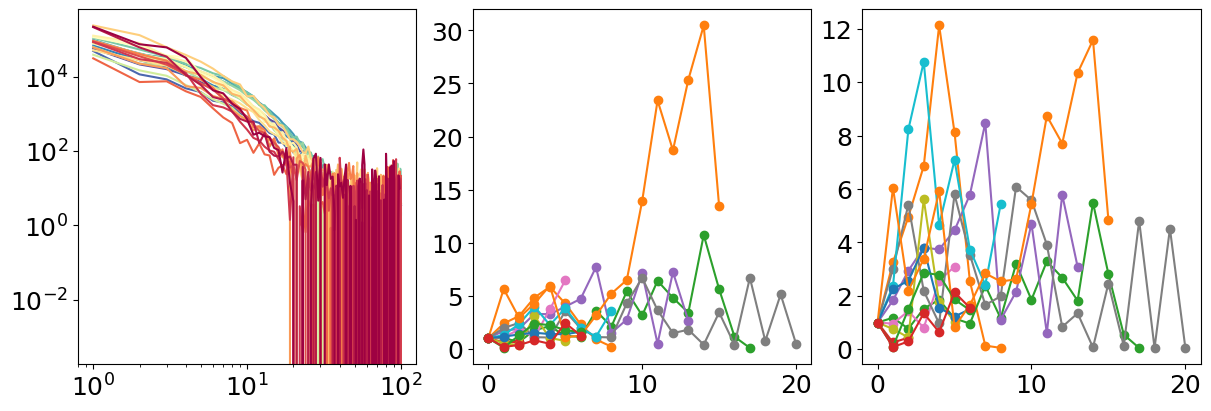

In [100]:
center = True
normalize = False
use_fast_sampling = True
use_spatial_eigenvectors = True
reliability_threshold = None
fraction_active_threshold = None
prms = dict(
    center=center,
    normalize=normalize,
    use_fast_sampling=use_fast_sampling,
    use_spatial_eigenvectors=use_spatial_eigenvectors,
    reliability_threshold=reliability_threshold,
    fraction_active_threshold=fraction_active_threshold,
)

mice = np.unique(results.mouse_names)
start_idx = 10
end_idx = 20

target = "reg_covariances"
_out = results.sel(squeeze_ones=True, **prms)
_data = _out[target]
_alphas = np.array(
    [fit_powerlaw_decay(_data[i], start_idx=start_idx, end_idx=end_idx, ignore_nans=True, verbose=False)[0] for i in range(len(_data))]
)

max_length = 0
mouse_covs = {mouse: None for mouse in mice}
mouse_alphas = {mouse: None for mouse in mice}
for mouse in mice:
    _idx_to_mouse = results.mouse_names == mouse
    _sessions = np.array([ses for ises, ses in enumerate(results.sessions) if _idx_to_mouse[ises]])
    _idx_sort = np.argsort([ses.session_uid for ses in _sessions])
    mouse_covs[mouse] = _data[_idx_to_mouse][_idx_sort]
    mouse_alphas[mouse] = _alphas[_idx_to_mouse][_idx_sort]
    max_length = max(max_length, len(_sessions))


def pad_with_nans(arr):
    if len(arr) < max_length:
        pad_width = max_length - len(arr)
        arr = np.pad(arr, ((0, pad_width), (0, 0)), mode="constant", constant_values=np.nan)
    return arr


all_covs = np.stack([pad_with_nans(mouse_covs[mouse]) for mouse in mice], axis=0)
all_alphas = np.stack([pad_with_nans(mouse_alphas[mouse][:, None]) for mouse in mice], axis=0)[..., 0]

num_front_dims = 5
slice_mid_dims = slice(8, 12)
front_covs = np.mean(all_covs[..., :num_front_dims], axis=2)
mid_covs = np.mean(all_covs[..., slice_mid_dims], axis=2)

xvals = np.arange(all_covs.shape[-1]) + 1
colors = plt.colormaps["Spectral_r"](np.linspace(0, 1, max_length))
fig, ax = plt.subplots(1, 3, figsize=(12, 4), layout="constrained")
for ml in range(max_length):
    ax[0].plot(xvals, np.nanmean(all_covs[:, ml], axis=0), color=colors[ml])

ax[0].set_xscale("log")
ax[0].set_yscale("log")

for mouse in range(len(mice)):
    ax[1].plot(front_covs[mouse] / front_covs[mouse][0], marker="o")
    ax[2].plot(mid_covs[mouse] / mid_covs[mouse][0], marker="o")

plt.show()

In [70]:
_sessions_random = np.random.permutation(_sessions)
# print("\n".join([ses.session_uid for ses in _sessions_random]))

_idx_sort = np.argsort([ses.session_uid for ses in _sessions_random])
# _sessions_sorted = sorted(_sessions_random, key=lambda ses: ses.session_uid)
_sessions_sorted = _sessions_random[_idx_sort]
print("\n".join([ses.session_uid for ses in _sessions_sorted]))

ATL012.2023-01-20.702
ATL012.2023-01-23.701
ATL012.2023-01-24.703
ATL012.2023-01-25.701
ATL012.2023-01-26.702
ATL012.2023-01-27.701
ATL012.2023-01-30.702
ATL012.2023-02-01.701
ATL012.2023-02-02.701
ATL012.2023-02-06.701
ATL012.2023-02-07.701
ATL012.2023-02-08.702
ATL012.2023-02-09.701
ATL012.2023-02-14.703
ATL012.2023-02-15.701
ATL012.2023-02-16.701
ATL012.2023-02-20.701
ATL012.2023-02-21.702
ATL012.2023-02-22.701
ATL012.2023-02-27.701
ATL012.2023-02-28.701
ATL012.2023-03-01.701
ATL012.2023-03-03.701
